In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

<h1>Normal Equation</h1>

In [5]:
m = 200

rng = np.random.default_rng(seed=42)

X = 2*rng.random((m, 1))
y = 4 + 3*X + rng.standard_normal((m, 1))

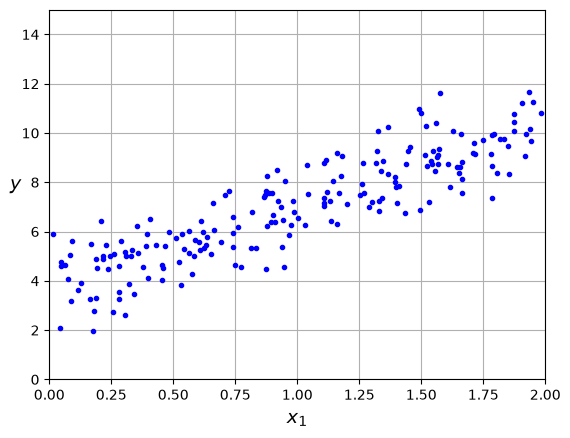

In [11]:
plt.plot(X, y, 'b.')

plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid(True)
plt.show()

$$\hat\theta = (X^TX)^{-1}X^Ty$$

<p>ALERTA: La multiplicacion matricial tiene una complejidad de tiempo de $O(n^3)$</p>

In [13]:
from sklearn.preprocessing import add_dummy_feature

In [17]:
X_b = add_dummy_feature(X)

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [16]:
X_b

array([[1.        , 1.5479121 ],
       [1.        , 0.87775688],
       [1.        , 1.71719584],
       [1.        , 1.39473606],
       [1.        , 0.1883547 ],
       [1.        , 1.9512447 ],
       [1.        , 1.5222794 ],
       [1.        , 1.57212861],
       [1.        , 0.25622727],
       [1.        , 0.90077188],
       [1.        , 0.74159605],
       [1.        , 1.85352998],
       [1.        , 1.28773024],
       [1.        , 1.64552323],
       [1.        , 0.8868284 ],
       [1.        , 0.45447744],
       [1.        , 1.10916957],
       [1.        , 0.12763451],
       [1.        , 1.65526234],
       [1.        , 1.2633288 ],
       [1.        , 1.51617548],
       [1.        , 0.70905194],
       [1.        , 1.94139605],
       [1.        , 1.78624224],
       [1.        , 1.55676699],
       [1.        , 0.38927742],
       [1.        , 0.93344201],
       [1.        , 0.08760753],
       [1.        , 0.30857898],
       [1.        , 1.36609791],
       [1.

In [19]:
theta_best

array([[3.69084138],
       [3.32960458]])

In [20]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)

y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

<b> ideal = ([[4],[10]])   ->   La diferencia es debida a el ruido aleatorio</b>

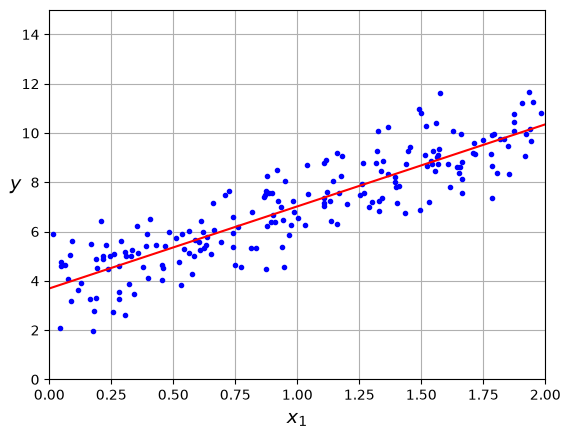

In [21]:
plt.plot(X, y, 'b.')
plt.plot(X_new, y_predict, 'r-', label='Prediction')

plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid(True)
plt.show()

<h1>Scikit-Learn</h1>

In [22]:
from sklearn.linear_model import LinearRegression

In [24]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [25]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

<p>Mismo resultado que lo que hicimos hace rato</p>

<h1>Gradient Descent</h1>

<p>Se calculan las pedientes de los errores (calculando la derivada) para encontrar el mínimo el cual será el origen</p>

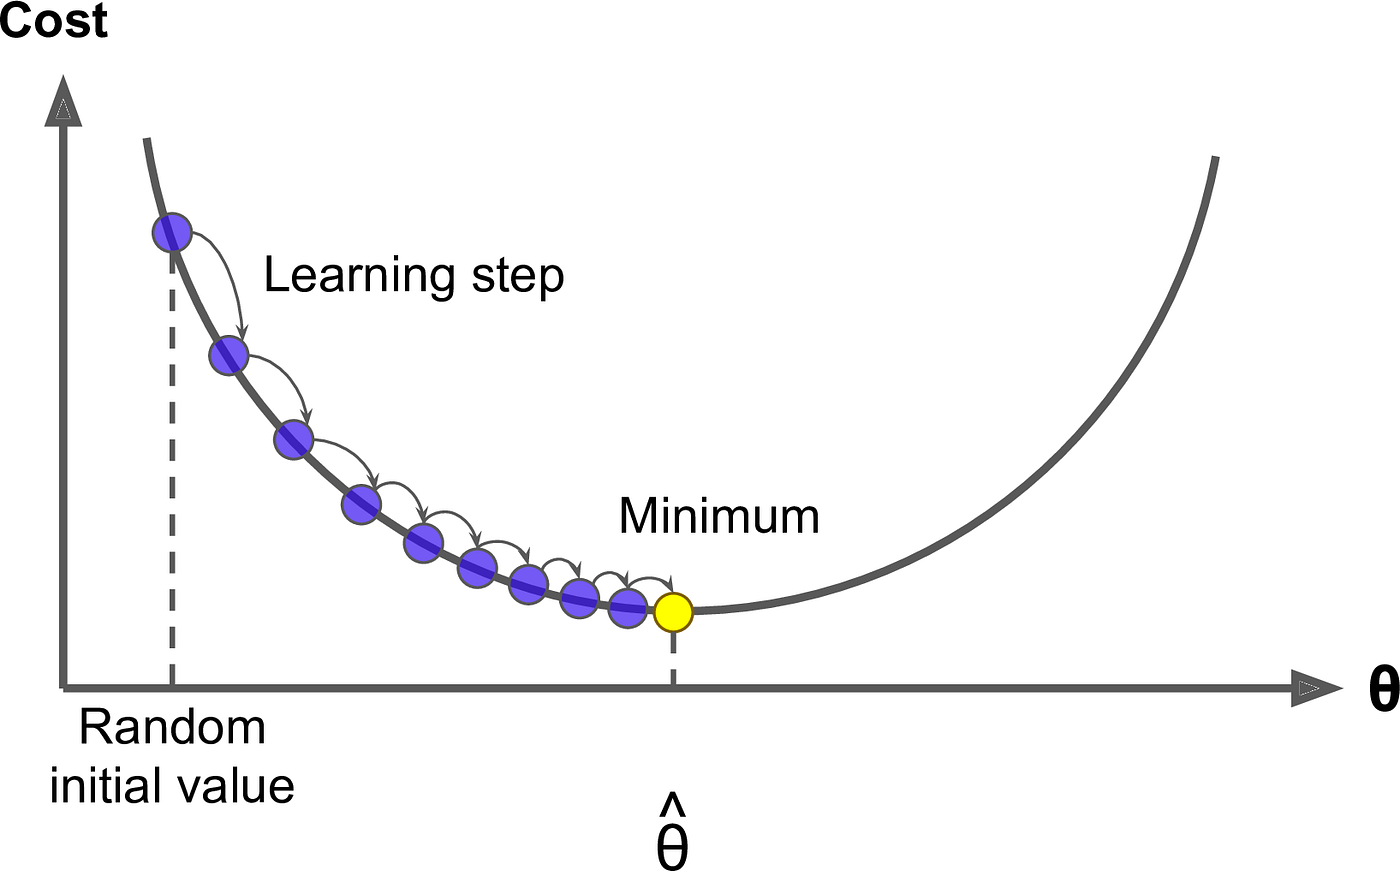

<h2>Batch Gradient Descent</h2>